In [1]:
# Block 1: Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully ✅")

All libraries imported successfully ✅


In [2]:
# Block 2: Load dataset and explore structure
df = pd.read_csv('Housing.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nBasic stats:")
display(df.describe())

Shape: (545, 13)

First 5 rows:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



Data types:
price               int64
area                int64
bedrooms            int64
bathrooms           int64
stories             int64
mainroad              str
guestroom             str
basement              str
hotwaterheating       str
airconditioning       str
parking             int64
prefarea              str
furnishingstatus      str
dtype: object

Missing values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Basic stats:


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [3]:
# Block 3: Encode categorical columns
# No missing values in this dataset — just encoding needed

# Step 1: Encode all binary yes/no columns -> 1/0
binary_cols = ['mainroad', 'guestroom', 'basement', 
               'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    df[col] = (df[col] == 'yes').astype(int)

# Step 2: Encode furnishingstatus with ordered mapping
# furnished > semi-furnished > unfurnished (higher = more furnished)
df['furnishingstatus'] = df['furnishingstatus'].map({
    'unfurnished': 0,
    'semi-furnished': 1,
    'furnished': 2
})

print("Encoding complete ✅")
print("\nSample after encoding:")
display(df.head())
print("\nAll columns numeric:", df.dtypes.apply(lambda x: x.name).unique())

Encoding complete ✅

Sample after encoding:


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,2
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,2
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,2
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,2



All columns numeric: <StringArray>
['int64']
Length: 1, dtype: str


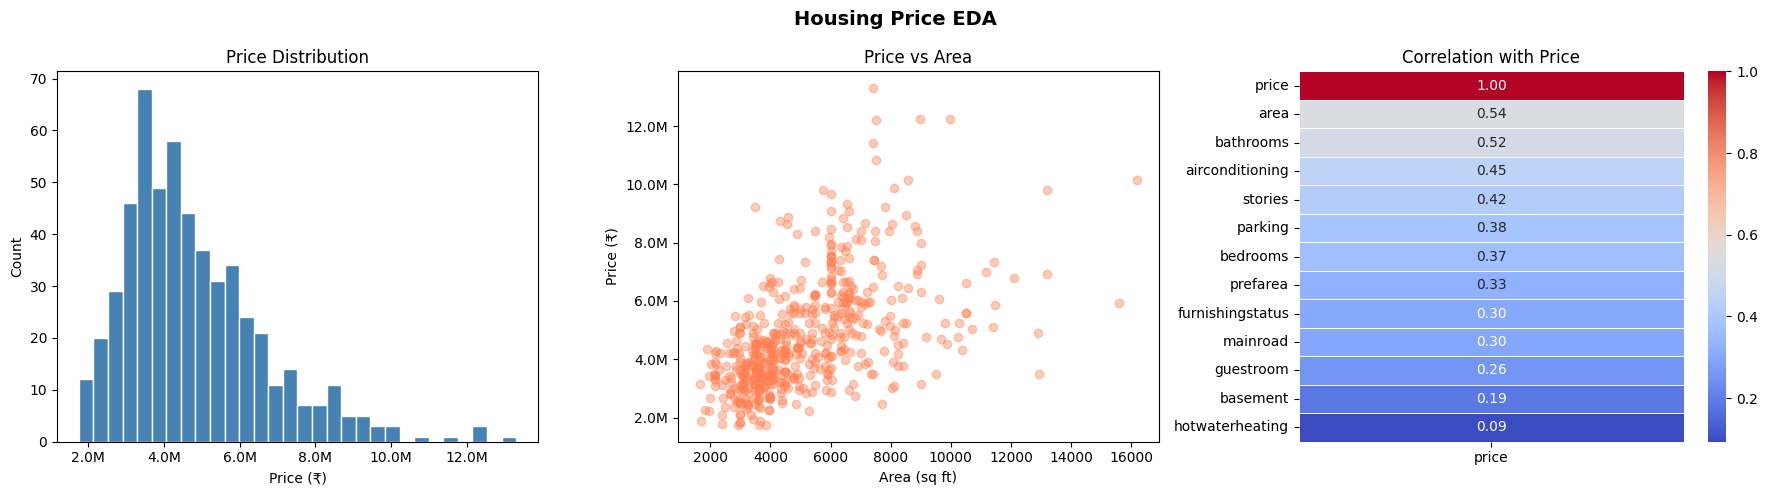

EDA plots saved ✅


In [4]:
# Block 4: Exploratory Data Analysis

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Housing Price EDA', fontsize=14, fontweight='bold')

# Plot 1: Price distribution
axes[0].hist(df['price'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution')
axes[0].set_xlabel('Price (₹)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Plot 2: Price vs Area (scatter)
axes[1].scatter(df['area'], df['price'], alpha=0.4, color='coral')
axes[1].set_title('Price vs Area')
axes[1].set_xlabel('Area (sq ft)')
axes[1].set_ylabel('Price (₹)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Plot 3: Correlation heatmap
corr = df.corr()
sns.heatmap(corr[['price']].sort_values('price', ascending=False),
            annot=True, fmt='.2f', cmap='coolwarm', ax=axes[2],
            linewidths=0.5)
axes[2].set_title('Correlation with Price')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plots saved ✅")

In [5]:
# Block 5: Define features, split data, scale

# All columns except target
FEATURES = [col for col in df.columns if col != 'price']
TARGET = 'price'

X = df[FEATURES]
y = df[TARGET]

print(f"Features used ({len(FEATURES)}):", FEATURES)
print(f"\nDataset size: {len(df)} rows")

# 80/20 split — random shuffle ok (not time series)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit ONLY on train
X_test_scaled  = scaler.transform(X_test)         # apply same scale to test

print("Scaling complete ✅")

Features used (12): ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Dataset size: 545 rows
Train: 436 rows | Test: 109 rows
Scaling complete ✅


In [6]:
# Block 6: Train Linear Regression and Gradient Boosting

# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
print("Linear Regression trained ✅")

# Model 2: Gradient Boosting
# n_estimators=300: 300 trees built sequentially, each correcting previous errors
# max_depth=4: each tree is shallow (prevents overfitting)
# learning_rate=0.05: small steps — more accurate but slower
# subsample=0.8: each tree trains on 80% of data — adds randomness, reduces overfitting
gb = GradientBoostingRegressor(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train_scaled, y_train)
print("Gradient Boosting trained ✅")

Linear Regression trained ✅
Gradient Boosting trained ✅


In [7]:
# Block 7: Evaluate both models

def evaluate(name, model, X_test, y_test):
    preds = model.predict(X_test)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  MAE  : ₹{mae:,.0f}")
    print(f"  RMSE : ₹{rmse:,.0f}")
    print(f"  R²   : {r2:.4f}")
    return preds, mae, rmse, r2

lr_preds, lr_mae, lr_rmse, lr_r2 = evaluate("Linear Regression",   lr, X_test_scaled, y_test)
gb_preds, gb_mae, gb_rmse, gb_r2 = evaluate("Gradient Boosting",   gb, X_test_scaled, y_test)

winner = "Linear Regression" if lr_r2 > gb_r2 else "Gradient Boosting"
print(f"\n🏆 Winner: {winner}")


  Linear Regression
  MAE  : ₹979,680
  RMSE : ₹1,331,071
  R²   : 0.6495

  Gradient Boosting
  MAE  : ₹960,220
  RMSE : ₹1,310,960
  R²   : 0.6600

🏆 Winner: Gradient Boosting


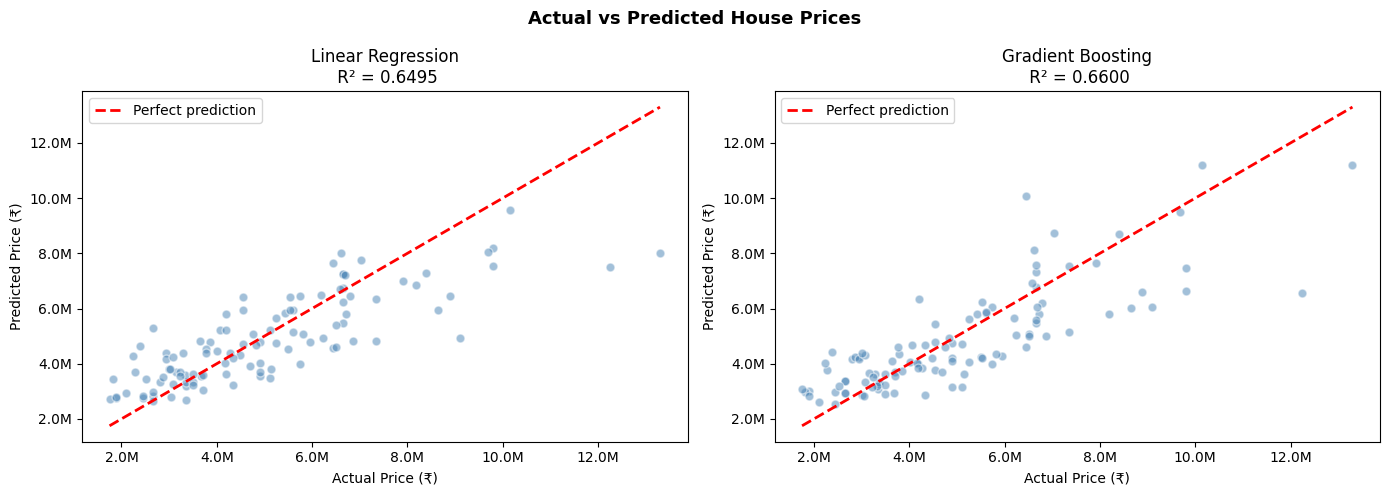

Plot saved ✅


In [8]:
# Block 8: Plot actual vs predicted for both models

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, preds, name, r2 in zip(
    axes,
    [lr_preds, gb_preds],
    ['Linear Regression', 'Gradient Boosting'],
    [lr_r2, gb_r2]
):
    ax.scatter(y_test, preds, alpha=0.5, color='steelblue', edgecolors='white', s=40)
    # Perfect prediction line
    mn, mx = y_test.min(), y_test.max()
    ax.plot([mn, mx], [mn, mx], 'r--', linewidth=2, label='Perfect prediction')
    ax.set_title(f'{name}\n R² = {r2:.4f}')
    ax.set_xlabel('Actual Price (₹)')
    ax.set_ylabel('Predicted Price (₹)')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
    ax.legend()

plt.suptitle('Actual vs Predicted House Prices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✅")

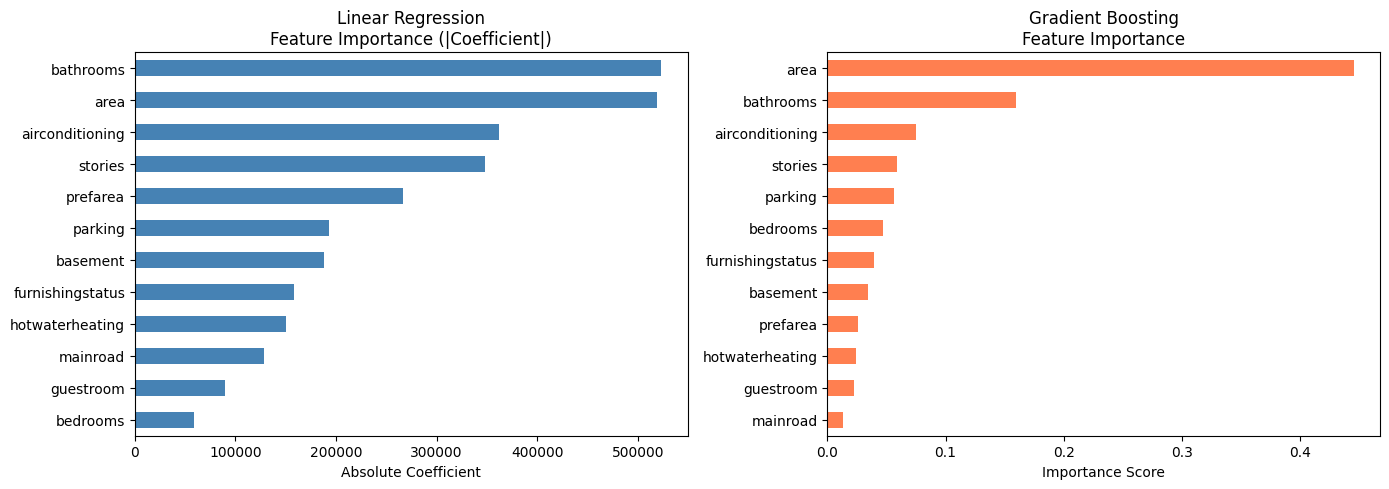

Feature importance saved ✅


In [9]:
# Block 9: Feature importance

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression — coefficients (absolute value = importance)
lr_importance = pd.Series(np.abs(lr.coef_), index=FEATURES).sort_values(ascending=True)
lr_importance.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Linear Regression\nFeature Importance (|Coefficient|)')
axes[0].set_xlabel('Absolute Coefficient')

# Gradient Boosting — built-in feature importances
gb_importance = pd.Series(gb.feature_importances_, index=FEATURES).sort_values(ascending=True)
gb_importance.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Gradient Boosting\nFeature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance saved ✅")

In [10]:
# Block 10: Predict price of a sample house

sample = pd.DataFrame([{
    'area': 6000,
    'bedrooms': 3,
    'bathrooms': 2,
    'stories': 2,
    'mainroad': 1,
    'guestroom': 0,
    'basement': 0,
    'hotwaterheating': 0,
    'airconditioning': 1,
    'parking': 1,
    'prefarea': 0,
    'furnishingstatus': 1   # semi-furnished
}])

sample_scaled = scaler.transform(sample)

lr_sample_pred = lr.predict(sample_scaled)[0]
gb_sample_pred = gb.predict(sample_scaled)[0]

print("Sample House Prediction")
print("="*40)
print(f"  Area: 6000 sq ft | 3 bed | 2 bath | 2 stories")
print(f"  AC: Yes | Semi-furnished | Main road: Yes")
print(f"\n  Linear Regression : ₹{lr_sample_pred:,.0f}")
print(f"  Gradient Boosting : ₹{gb_sample_pred:,.0f}")

Sample House Prediction
  Area: 6000 sq ft | 3 bed | 2 bath | 2 stories
  AC: Yes | Semi-furnished | Main road: Yes

  Linear Regression : ₹6,118,314
  Gradient Boosting : ₹7,500,558


In [ ]:
# Block 11: Final Summary

print("=" * 55)
print("       TASK 6 — HOUSE PRICE PREDICTION SUMMARY")
print("=" * 55)
print(f"\n📦 Dataset   : Housing.csv — 545 houses, 12 features")
print(f"🎯 Target    : House Price (₹)")
print(f"✂️  Split     : 436 train | 109 test (80/20)")

print(f"\n{'Model':<25} {'MAE':>12} {'RMSE':>12} {'R²':>8}")
print("-" * 60)
print(f"{'Linear Regression':<25} ₹{lr_mae:>10,.0f} ₹{lr_rmse:>10,.0f} {lr_r2:>8.4f}")
print(f"{'Gradient Boosting':<25} ₹{gb_mae:>10,.0f} ₹{gb_rmse:>10,.0f} {gb_r2:>8.4f}")

print(f"\n🏆 Best Model: {'Linear Regression' if lr_r2 > gb_r2 else 'Gradient Boosting'}")
print(f"\n💡 Key Findings:")
print(f"   1. Area is the strongest predictor of house price")
print(f"   2. AC, prefarea, and bathrooms are next most important")
print(f"   3. hotwaterheating has the weakest effect")
print(f"   4. Gradient Boosting handles non-linear relationships better")
print(f"      but may overfit on this small (545 row) dataset")

       TASK 6 — HOUSE PRICE PREDICTION SUMMARY

📦 Dataset   : Housing.csv — 545 houses, 12 features
🎯 Target    : House Price (₹)
✂️  Split     : 436 train | 109 test (80/20)

Model                              MAE         RMSE       R²
------------------------------------------------------------
Linear Regression         ₹   979,680 ₹ 1,331,071   0.6495
Gradient Boosting         ₹   960,220 ₹ 1,310,960   0.6600

🏆 Best Model: Gradient Boosting

💡 Key Findings:
   1. Area is the strongest predictor of house price
   2. AC, prefarea, and bathrooms are next most important
   3. hotwaterheating has the weakest effect
   4. Gradient Boosting handles non-linear relationships better
      but may overfit on this small (545 row) dataset

✅ Notebook complete!
